In [1]:
import os
import sys

In [2]:
# this adds the module to the path so that it can be used to call the functions
root = os.path.abspath(os.path.join(os.path.dirname(os.getcwd())))
sys.path.append(root)

In [3]:
from src.classes import Node, Cirq_Tableau
import numpy as np

# First Attempt

In [9]:
def couple_dict_maker(coupling_list, layout_map):
    couple_dict = dict()
    for couple in coupling_list:
        if couple[0] not in layout_map.keys() and couple[1] not in layout_map.keys():
            continue
        elif couple[0] in layout_map.keys() and couple[1] not in layout_map.keys():
            ctrl = layout_map[couple[0]]
            couple_dict[ctrl] = [[],[]]
        elif couple[0] not in layout_map.keys() and couple[1] in layout_map.keys():
            targ = layout_map[couple[1]]
            couple_dict[targ] = [[],[]]
        else:
            ctrl = layout_map[couple[0]]
            targ = layout_map[couple[1]]
            cple = [ctrl,targ]
            if ctrl in couple_dict:
                couple_dict[ctrl][0].append(cple)
            else:
                couple_dict[ctrl] = [[cple],[]]

            if targ in couple_dict:
                couple_dict[targ][1].append(cple)
            else:
                couple_dict[targ] = [[],[cple]]

    return couple_dict

In [7]:
def least_connected(couple_dict):
    connections = float('inf')
    indexes = []
    
    for ndx in couple_dict.keys():
        new_connections = len(couple_dict[ndx][0]) + len(couple_dict[ndx][1])
        if new_connections < connections:
            connections = new_connections
            indexes.append(ndx)
        elif new_connections == connections:
            indexes.append(ndx)

    return indexes

In [ ]:
def generate_ops(tableau, coupling_dict, pauli_ndx, indexes):
    ops = [] # list to hold tuples (node index to remove, operations to remove that index)
    for ndx in indexes:
        operations = []
        if ~tab.xs[pauli_ndx][ndx] & ~tab.zs[pauli_ndx][ndx]: # index has an I already solved
            continue
        
        ctrl_list, targ_list = coupling_dict[ndx][0], coupling_dict[ndx][1]

        for couple in ctrl_list:
            op = []
            if ~tab.xs[pauli_ndx][couple[1]] & ~tab.zs[pauli_ndx][couple[1]]: # target is I
                operations.append([("CX", couple[0], couple[1]),("CX", couple[1], couple[0]),("CX", couple[0], couple[1])])
                continue
                
            if tab.xs[pauli_ndx][couple[0]] & ~tab.zs[pauli_ndx][couple[0]]: #control is X
                op.append(("H", couple[0]))
            elif tab.xs[pauli_ndx][couple[0]] & tab.zs[pauli_ndx][couple[0]]: #control is Y
                op.append(("S", couple[0]))
                op.append(("H", couple[0]))
                
            if tab.xs[pauli_ndx][couple[1]] & ~tab.zs[pauli_ndx][couple[1]]: #target is X
                operations.append(op + [("H", couple[1]), ("CX", couple[0], couple[1])])
                operations.append(op + [("S", couple[1]), ("CX", couple[0], couple[1])])
            else:
                operations.append(op + [("CX", couple[0], couple[1])])

        for couple in targ_list:
            op = []
            if ~tab.xs[pauli_ndx][couple[0]] & ~tab.zs[pauli_ndx][couple[0]]: # control is I
                operations.append([("CX", couple[0], couple[1]),("CX", couple[1], couple[0]),("CX", couple[0], couple[1])])
                continue
                
            if tab.xs[pauli_ndx][couple[1]] & tab.zs[pauli_ndx][couple[1]]: #target is Y
                op.append(("S", couple[1]))
            elif ~tab.xs[pauli_ndx][couple[1]] & tab.zs[pauli_ndx][couple[1]]: #target is Z
                op.append(("H", couple[1]))
                
            if ~tab.xs[pauli_ndx][couple[0]] & tab.zs[pauli_ndx][couple[0]]: #control is Z
                operations.append(op + [("H", couple[0]), ("CX", couple[0], couple[1])])
                operations.append(op + [("H", couple[0]),("S", couple[0]), ("CX", couple[0], couple[1])])
            else:
                operations.append(op + [("CX", couple[0], couple[1])])
                
        ops.append((ndx, operations))
    return ops

In [ ]:
def apply(tableau, operation):
    tab = tableau.copy()

    for action in operation:
        match action[0]:
            case "CX":
                tab.apply_CX(action[1], action[2])
            case "S":
                tab.apply_S(action[1])
            case "H":
                tab.apply_H(action[1])
                
    ctrl, targ = operation[-1][1], operation[-1][2]

In [ ]:
def hrdwre_aware_solve(tableau, pauli_ndx, ndx_list, coupling_list, layout_map):
    tab = tableau.copy()
    reduction = []
    
    coupling_dict = couple_dict_maker(coupling_list)
    
    while True:
        operation = []
        benefit = -float('inf')
        rmv_ndxs = [0] # placeholder number for the time being - there is definitely a better way to do this
        table = None

        # break condition 
        if sum(tab.xs[ndx] | tab.zs[ndx]) == 1:
            break

        least_ndxs = least_connected(coupling_dict)
        operations = generate_ops(tab,coupling_dict,pauli_ndx, least_ndxs)
        if operations:
            for op_tuple in operations:
                for op in op_tuple[1]:
                    new_tab, gain = apply(tab, op)
                    if gain > benefit:
                        benefit = gain
                        operation = op
                        table = new_tab
                        rmv_ndx[0] = op_tuple[0]
        else:
            rmv_ndxs = least_ndxs

# Second Attempt

In [4]:
from qiskit.circuit import QuantumCircuit, Parameter, ParameterVector
from qiskit.transpiler.passes import CommutativeCancellation, DenseLayout
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit_ibm_runtime.fake_provider import FakeAlgiers, FakeAlmadenV2
from qiskit.transpiler import CouplingMap

In [5]:
def generate_new_couple_list(coupling_list, register, phys_virt_map):
    couple_list = []
    key_list = phys_virt_map.keys()
    for couple in coupling_list:
        if couple[0] in key_list and couple[1] in key_list:
            couple_list.append([register.index(phys_virt_map[couple[0]]), register.index(phys_virt_map[couple[1]])])

    return couple_list

In [6]:
def ibm_layout(num_qubits, machine=FakeAlmadenV2, algorithm=DenseLayout): 
    
    backend = machine()
    
    original_coupling_list = backend.configuration().coupling_map
    original_cmap = CouplingMap(original_coupling_list)
    instance = algorithm(coupling_map=original_cmap)
    instance.run(circuit_to_dag(QuantumCircuit(num_qubits)))

    phys_virt_map = instance.property_set["layout"].get_physical_bits()
    register = list(instance.property_set['layout'].get_registers())[0]

    new_coupling_list = generate_new_couple_list(original_coupling_list, register, phys_virt_map)
    distance_matrix = np.array(CouplingMap(new_coupling_list).distance_matrix)

    return distance_matrix, new_coupling_list, CouplingMap(new_coupling_list)

In [7]:
# TODO: write a more efficient pruning algorithm
def prune(tableau, ndx_list):
    '''
    Function to remove rows in a tableau with only a single nonidentity operation
    
    :param tableau: Cirq_Tableau to act on
    '''
    prn_ndxs = [] # list to hold all row indices to be pruned
    
    tab = tableau.copy() # copy of tableau to work on

    single_q = [] # loist of single qubit operations 
    
    track_ndx = ndx_list.copy()
    
    rmv_ndx = []
    # extracts x, z and sign arrays
    x, z, s = tab.xs, tab.zs, tab.ss

    # bitwise ORs x and z arrays in tableau to create array where nonidentity operation indices have 1 in them
    weight_array = x | z

    # loop that checks through each row to find out if it has a Pauli weight of 1
    for r_ndx in range(len(weight_array)):
        if sum(weight_array[r_ndx])  == 1:
            val = track_ndx[r_ndx]
            # appends index to be pruned if Pauli weight == 1
            prn_ndxs.append(r_ndx)
            rmv_ndx.append(val)
            # checks what type of Pauli is on that index X, Y or Z and appends to path with action weight of zero 
            if sum(z[r_ndx]) == 0:
                if s[r_ndx] == 0:
                    single_q.append(("X", int(np.argmax(x[r_ndx] == 1)), val))
                else:
                    single_q.append(("-X", int(np.argmax(x[r_ndx] == 1)), val))
            elif sum(x[r_ndx]) == 0:
                if s[r_ndx] == 0:
                    single_q.append(("Z", int(np.argmax(z[r_ndx] == 1)), val))
                else:
                    single_q.append(("-Z", int(np.argmax(z[r_ndx] == 1)), val))
            else:
                if s[r_ndx] == 0:
                    single_q.append(("Y", int(np.argmax(x[r_ndx] == 1)), val))
                else:
                    single_q.append(("-Y", int(np.argmax(x[r_ndx] == 1)), val))
                    
        elif sum(weight_array[r_ndx])  == 0: # elif removes fully I lines 
            x, z, s = np.delete(x, r_ndx, axis=0), np.delete(z, r_ndx, axis=0), np.delete(s, r_ndx)
            
    # prunes rows 
    x, z, s = np.delete(x, prn_ndxs, axis=0), np.delete(z, prn_ndxs, axis=0), np.delete(s, prn_ndxs)
    column_num = len(x[0]) if x.size != 0 else 0 
    row_num = len(x)
    new_ndx_list = [x for x in ndx_list if x not in rmv_ndx]
    # updates tableau and returns it 
    tab.xs, tab.zs, tab.ss, tab.column_num, tab.row_num = x, z, s, column_num,row_num
    return tab, single_q, new_ndx_list

In [23]:
def generate_ops(tableau, pauli_ndx, distance_matrix, coupling_list):
    tab = tableau.copy()
    ops = []
    occupancy = tab.xs[pauli_ndx] | tab.zs[pauli_ndx]

    dist_vals = np.matmul(distance_matrix, occupancy) * occupancy
    #print(dist_vals)
    ndxs = np.where(dist_vals == np.max(dist_vals))[0]
    #print(ndxs)
    for ndx in ndxs:
        for couple in coupling_list:
            #if (~tab.xs[pauli_ndx][couple[1]] & ~tab.zs[pauli_ndx][couple[1]])& (~tab.xs[pauli_ndx][couple[1]] & ~tab.zs[pauli_ndx][couple[1]])
            op = []
            if couple[0] == ndx: # qubit to be eliminated lies on control
                if  int(not tab.xs[pauli_ndx][couple[1]]) & int(not tab.zs[pauli_ndx][couple[1]]): # target is I
                    ops.append([("CX", ndx, couple[1]),("CX", couple[1], ndx),("CX", ndx, couple[1])])
                    continue 
                    
                if tab.xs[pauli_ndx][ndx] & ~tab.zs[pauli_ndx][ndx]: #control is X
                    op.append(("H", ndx))
                elif tab.xs[pauli_ndx][ndx] & tab.zs[pauli_ndx][ndx]: #control is Y
                    op.append(("S", ndx))
                    op.append(("H", ndx))
                    

                if tab.xs[pauli_ndx][couple[1]] & ~tab.zs[pauli_ndx][couple[1]]: #target is X
                    ops.append(op + [("H", couple[1]), ("CX", ndx, couple[1])])
                    ops.append(op + [("S", couple[1]), ("CX", ndx, couple[1])])
                else:
                    ops.append(op + [("CX", ndx, couple[1])])

            elif couple[1] == ndx:# qubit to be eliminated lies on target
                if int(not tab.xs[pauli_ndx][couple[0]]) & int( not tab.zs[pauli_ndx][couple[0]]): # control is I
                    ops.append([("CX", couple[0], ndx),("CX", ndx, couple[0]),("CX", couple[0], ndx)])
                    continue
                
                if tab.xs[pauli_ndx][ndx] & tab.zs[pauli_ndx][ndx]: #target is Y
                    op.append(("S", ndx))
                elif ~tab.xs[pauli_ndx][ndx] & tab.zs[pauli_ndx][ndx]: #target is Z
                    op.append(("H", ndx))
                
                if ~tab.xs[pauli_ndx][couple[0]] & tab.zs[pauli_ndx][couple[0]]: #control is Z
                    ops.append(op + [("H", couple[0]), ("CX", couple[0], ndx)])
                    ops.append(op + [("H", couple[0]),("S", couple[0]), ("CX", couple[0], ndx)])
                else:
                    ops.append(op + [("CX", couple[0], ndx)])
    #print(ops)
    return ops

In [9]:
def best_oper(tableau, op_list, distance_matrix):
    
    tab = None
    operation = None
    distance = float('inf')

    for op in op_list:
        table = tableau.copy()

        for action in op:
            match action[0]:
                case "CX":
                    table.apply_CX(action[1], action[2])
                case "S":
                    table.apply_S(action[1])
                case "H":
                    table.apply_H(action[1])
        
        occupancy = table.xs | table.zs

        dist_vals = np.matmul(distance_matrix, occupancy.T) * occupancy.T

        dist = sum(sum(dist_vals))

        if dist < distance:
            operation = op
            tab = table

    return tab, operation

In [21]:
def hrdwre_awr_solve(tableau, pauli_ndx, ndx_list, distance_matrix, coupling_list):

    tab = tableau.copy()
    reduction = []

    while sum(tab.xs[pauli_ndx] | tab.zs[pauli_ndx]) != 1:

        operations = generate_ops(tab, pauli_ndx, distance_matrix, coupling_list)
        tab, best_op  = best_oper(tab, operations, distance_matrix)
        
        reduction += best_op
        print(reduction)
    tab, single_q, new_ndx_list = prune(tab, ndx_list)
    reduction += single_q
    return tab, reduction, new_ndx_list

In [11]:
test = Cirq_Tableau([
        "YXIIIIIIIIYXIIIIIIII",
        "XXIIIIIIIIYXIIIIIIII",
        "YYIIIIIIIIYXIIIIIIII",
        "XYIIIIIIIIYXIIIIIIII",
        "YXIIIIIIIIYYIIIIIIII",
        "XXIIIIIIIIYYIIIIIIII",
        "YYIIIIIIIIYYIIIIIIII",
        "XYIIIIIIIIYYIIIIIIII",
        "YXIIIIIIIIXXIIIIIIII",
        "XXIIIIIIIIXXIIIIIIII",
        "YYIIIIIIIIXXIIIIIIII",
        "XYIIIIIIIIXXIIIIIIII",
        "YXIIIIIIIIXYIIIIIIII",
        "XXIIIIIIIIXYIIIIIIII",
        "YYIIIIIIIIXYIIIIIIII",
        "XYIIIIIIIIXYIIIIIIII"
    ])

In [12]:
test_2 = Cirq_Tableau([
        "YZZZZZZZZZXIIIIIIIII",
        "XZZZZZZZZZXIIIIIIIII",
        "YZZZZZZZZZYIIIIIIIII",
        "XZZZZZZZZZYIIIIIIIII"
    ],)

In [13]:
num = test_2.column_num
num

20

In [14]:
distance_matrix, coupling_list, cmap = ibm_layout(num)

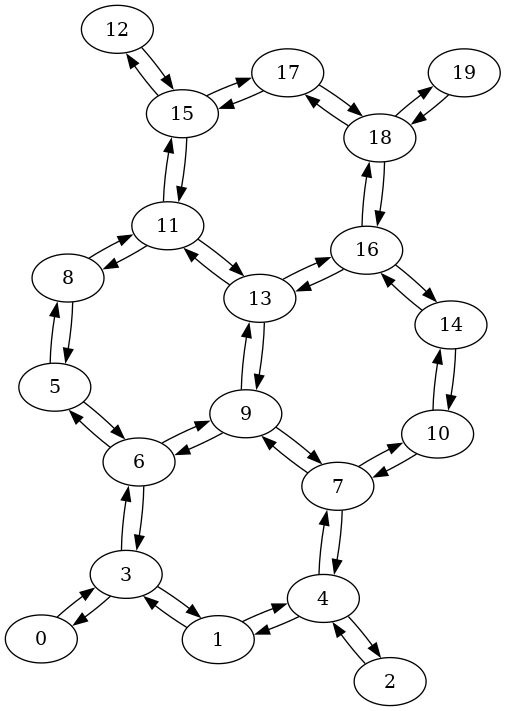

In [15]:
cmap.draw()

In [16]:
index_list = list(range(num))

In [28]:
tab, reduction, new_ndx_list = hrdwre_awr_solve(test_2, 3, index_list, distance_matrix, coupling_list)

[('H', 8), ('H', 5), ('S', 5), ('CX', 5, 8)]
[('H', 8), ('H', 5), ('S', 5), ('CX', 5, 8), ('S', 10), ('H', 7), ('S', 7), ('CX', 7, 10)]
[('H', 8), ('H', 5), ('S', 5), ('CX', 5, 8), ('S', 10), ('H', 7), ('S', 7), ('CX', 7, 10), ('H', 2), ('H', 4), ('S', 4), ('CX', 4, 2)]
[('H', 8), ('H', 5), ('S', 5), ('CX', 5, 8), ('S', 10), ('H', 7), ('S', 7), ('CX', 7, 10), ('H', 2), ('H', 4), ('S', 4), ('CX', 4, 2), ('S', 5), ('H', 5), ('CX', 5, 6)]
[('H', 8), ('H', 5), ('S', 5), ('CX', 5, 8), ('S', 10), ('H', 7), ('S', 7), ('CX', 7, 10), ('H', 2), ('H', 4), ('S', 4), ('CX', 4, 2), ('S', 5), ('H', 5), ('CX', 5, 6), ('H', 0), ('CX', 0, 3)]
[('H', 8), ('H', 5), ('S', 5), ('CX', 5, 8), ('S', 10), ('H', 7), ('S', 7), ('CX', 7, 10), ('H', 2), ('H', 4), ('S', 4), ('CX', 4, 2), ('S', 5), ('H', 5), ('CX', 5, 6), ('H', 0), ('CX', 0, 3), ('H', 9), ('H', 6), ('S', 6), ('CX', 6, 9)]
[('H', 8), ('H', 5), ('S', 5), ('CX', 5, 8), ('S', 10), ('H', 7), ('S', 7), ('CX', 7, 10), ('H', 2), ('H', 4), ('S', 4), ('CX', 4,

In [29]:
reduction

[('H', 8),
 ('H', 5),
 ('S', 5),
 ('CX', 5, 8),
 ('S', 10),
 ('H', 7),
 ('S', 7),
 ('CX', 7, 10),
 ('H', 2),
 ('H', 4),
 ('S', 4),
 ('CX', 4, 2),
 ('S', 5),
 ('H', 5),
 ('CX', 5, 6),
 ('H', 0),
 ('CX', 0, 3),
 ('H', 9),
 ('H', 6),
 ('S', 6),
 ('CX', 6, 9),
 ('S', 7),
 ('CX', 4, 7),
 ('S', 6),
 ('H', 3),
 ('S', 3),
 ('CX', 3, 6),
 ('S', 4),
 ('H', 1),
 ('S', 1),
 ('CX', 1, 4),
 ('CX', 0, 3),
 ('CX', 3, 0),
 ('CX', 0, 3),
 ('CX', 3, 1),
 ('CX', 1, 3),
 ('CX', 3, 1),
 ('S', 3),
 ('CX', 0, 3),
 ('Y', 0, 3)]

In [78]:
1 & (~0 ^ 1)

0

In [79]:
1 ^ 1

0

In [74]:
if ~1 & ~1:
    print(1)

1


In [36]:
occupancy = test.xs[0] | test.zs[0]
occupancy

array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [41]:
a = np.matmul(distance_matrix, occupancy.T)

In [40]:
distance_matrix

array([[0., 2., 4., 1., 3., 3., 2., 4., 4., 3., 5., 5., 7., 4., 6., 6.,
        5., 7., 6., 7.],
       [2., 0., 2., 1., 1., 3., 2., 2., 4., 3., 3., 5., 7., 4., 4., 6.,
        5., 7., 6., 7.],
       [4., 2., 0., 3., 1., 5., 4., 2., 6., 3., 3., 5., 7., 4., 4., 6.,
        5., 7., 6., 7.],
       [1., 1., 3., 0., 2., 2., 1., 3., 3., 2., 4., 4., 6., 3., 5., 5.,
        4., 6., 5., 6.],
       [3., 1., 1., 2., 0., 4., 3., 1., 5., 2., 2., 4., 6., 3., 3., 5.,
        4., 6., 5., 6.],
       [3., 3., 5., 2., 4., 0., 1., 3., 1., 2., 4., 2., 4., 3., 5., 3.,
        4., 4., 5., 6.],
       [2., 2., 4., 1., 3., 1., 0., 2., 2., 1., 3., 3., 5., 2., 4., 4.,
        3., 5., 4., 5.],
       [4., 2., 2., 3., 1., 3., 2., 0., 4., 1., 1., 3., 5., 2., 2., 4.,
        3., 5., 4., 5.],
       [4., 4., 6., 3., 5., 1., 2., 4., 0., 3., 5., 1., 3., 2., 4., 2.,
        3., 3., 4., 5.],
       [3., 3., 3., 2., 2., 2., 1., 1., 3., 0., 2., 2., 4., 1., 3., 3.,
        2., 4., 3., 4.],
       [5., 3., 3., 4., 2., 4.

In [42]:
a * occupancy

array([12., 10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 12., 14.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.])

In [50]:
~1 & ~1

-2

In [51]:
if -2:
    print(1)

1


In [53]:
int(not 1)

0

In [56]:
~0 ^ 0

-1

In [80]:
1 & 1

1

In [59]:
int(np.array([True, False]))

TypeError: only length-1 arrays can be converted to Python scalars